# **CHAPTER 5: Support Vector Machines**

**SVM finds the separating line (or plane) that maximizes the distance between classes, and this line is determined only by the closest training points called support vectors.**

Remember for Exams

- Decision Boundary → The line separating classes.
- Margin → Distance between classes and the boundary.
- Large Margin Classification → Choosing the widest possible margin.
- Support Vectors → Closest data points to the boundary.
- Goal of SVM → Maximize the margin to improve generalization on unseen data.

## **Soft Margin Classification**



### **Easy Memory Trick**
- Hard Margin = Strict Teacher → No mistakes allowed.
- Soft Margin = Practical Teacher → A few mistakes are okay if overall performance is better.


| Feature                            | Hard Margin | Soft Margin    |
| ---------------------------------- | ----------- | -------------- |
| Misclassification Allowed?         | No          | Yes            |
| Handles Outliers?                  | Poorly      | Well           |
| Requires Perfectly Separable Data? | Yes         | No             |
| Generalization                     | Often Worse | Usually Better |
| Used in Practice?                  | Rarely      | Very Common    |


### **The C Parameter**

- The parameter C controls how strict the SVM is.

**Large C**
- Tries to classify every point correctly.
- Behaves more like Hard Margin.
- Smaller margin.
- More sensitive to outliers.

**Small C**
- Allows more violations.
- Wider margin.
- More tolerant of outliers.
- Better generalization in many cases.


The Trade-off: A bunch of points (the circled ones) end up sitting right inside the street. These are called margin violations.


In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn import datasets
from sklearn.pipeline import Pipeline

iris = datasets.load_iris()

X = iris['data'][:, (2,3)]
y = (iris["target"] == 2).astype(np.float64)

In [6]:
svm_clf = Pipeline((
    ('scaler', StandardScaler()),
    ('LinearSVC', LinearSVC(C=1, loss='hinge'))
))

In [7]:
svm_clf.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()),
                ('LinearSVC', LinearSVC(C=1, loss='hinge'))])

In [8]:
svm_clf.predict([[5.5, 1.7]])

array([1.])

## **Nonlinear SVM Classification**

In [24]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


poly_svm_clf = Pipeline((
    ('poly_features', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('svm_clf', LinearSVC(C=0.10000, loss='hinge'))
))

poly_svm_clf.fit(X, y)

Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=0.1, loss='hinge'))])

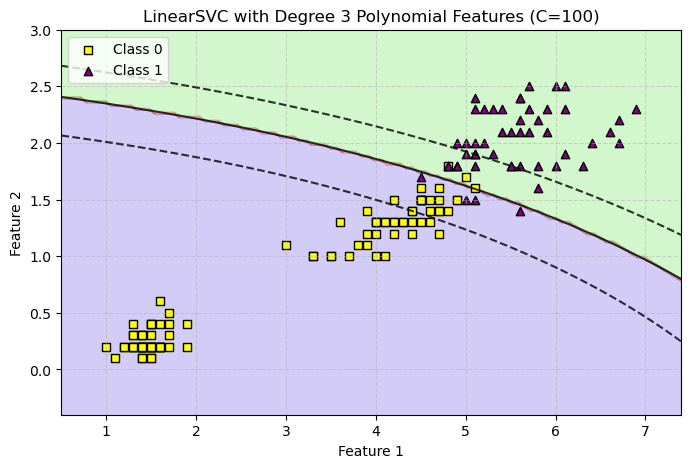

In [25]:
import matplotlib.pyplot as plt

def plot_predictions(clf, axes):
    """Generates a grid of points and plots the decision boundary."""
    # 1. Create a dense grid of points over the feature space
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    
    # 2. Flatten the grid to pass through the pipeline
    X_grid = np.c_[x0.ravel(), x1.ravel()]
    
    # 3. Predict the class and get the raw decision scores
    y_pred = clf.predict(X_grid).reshape(x0.shape)
    y_decision = clf.decision_function(X_grid).reshape(x0.shape)
    
    # 4. Plot the filled decision regions (light blue/red tinted background)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    
    # 5. Plot the solid decision boundary (where score = 0) and margins (where score = +/-1)
    plt.contour(x0, x1, y_decision, levels=[-1, 0, 1], alpha=0.8,
                linestyles=['--', '-', '--'], colors=['black', 'black', 'black'])

# --- How to use it with your data ---

# Set your plot limits based on your actual data ranges [xmin, xmax, ymin, ymax]
# For example, if you are using the moon dataset or iris petal data:
axes_limits = [X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 
               X[:, 1].min() - 0.5, X[:, 1].max() + 0.5]

plt.figure(figsize=(8, 5))

# Plot your background decision boundary
plot_predictions(poly_svm_clf, axes_limits)

# Plot your actual scatter points on top
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", color="yellow", label="Class 0", edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", color="purple", label="Class 1", edgecolors='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc="upper left")
plt.title(f"LinearSVC with Degree 3 Polynomial Features (C=100)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# **Polynomial Kernel**


In [31]:
from sklearn.svm import SVC

poly_svc_clf = Pipeline((
    ('scaler', StandardScaler()),
    ('svm_clf', SVC(kernel='poly', degree=10, coef0=1, C=10))
))

poly_svc_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=10, coef0=1, degree=10, kernel='poly'))])

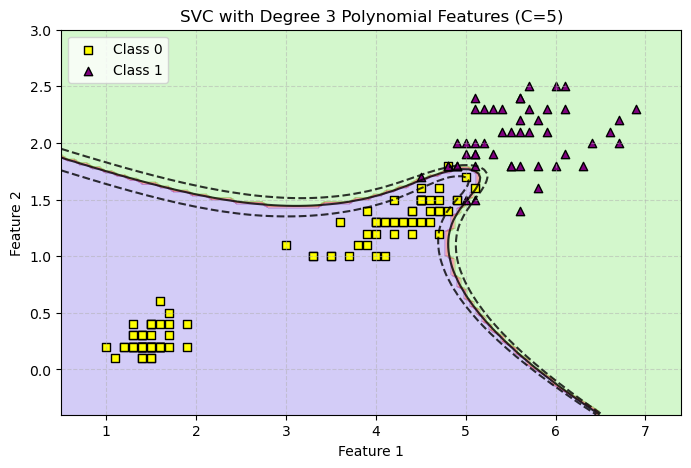

In [32]:
# --- How to use it with your data ---

# Set your plot limits based on your actual data ranges [xmin, xmax, ymin, ymax]
# For example, if you are using the moon dataset or iris petal data:
axes_limits = [X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 
               X[:, 1].min() - 0.5, X[:, 1].max() + 0.5]

plt.figure(figsize=(8, 5))

# Plot your background decision boundary
plot_predictions(poly_svc_clf, axes_limits)

# Plot your actual scatter points on top
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", color="yellow", label="Class 0", edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", color="purple", label="Class 1", edgecolors='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc="upper left")
plt.title(f"SVC with Degree 3 Polynomial Features (C=5)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## **Adding Similarity Features Or Similarity Function**
- Another technique to tackle nonlinear problems is to add features computed using a similarity function that measures how much each instance resembles a particular landmark

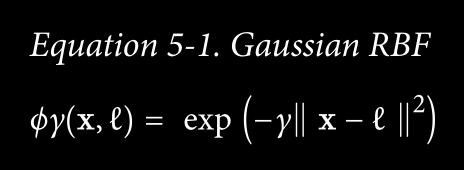

Gaussian Radial Basis Function (RBF)
with γ

## **Gaussian RBF Kernel**

In [39]:
rbf_kernel_svm_clf = Pipeline((
("scaler", StandardScaler()),
("svm_clf", SVC(kernel="rbf", gamma=5, C=1))
))
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('svm_clf', SVC(C=1, gamma=5))])

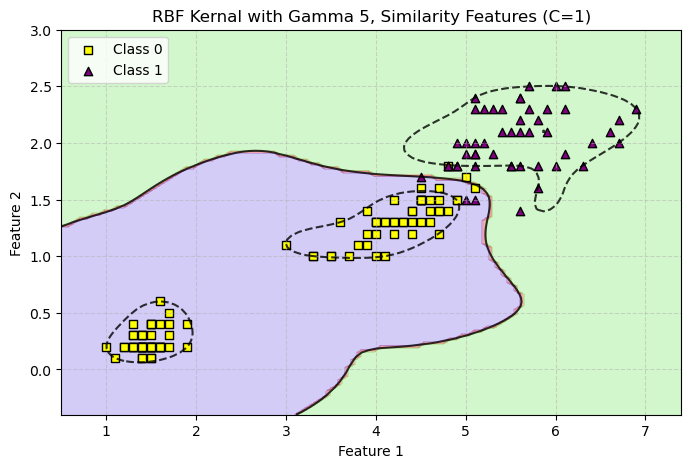

In [41]:
# --- How to use it with your data ---

# Set your plot limits based on your actual data ranges [xmin, xmax, ymin, ymax]
# For example, if you are using the moon dataset or iris petal data:
axes_limits = [X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 
               X[:, 1].min() - 0.5, X[:, 1].max() + 0.5]

plt.figure(figsize=(8, 5))

# Plot your background decision boundary
plot_predictions(rbf_kernel_svm_clf, axes_limits)

# Plot your actual scatter points on top
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", color="yellow", label="Class 0", edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", color="purple", label="Class 1", edgecolors='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc="upper left")
plt.title(f"RBF Kernal with Gamma 5, Similarity Features (C=1)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# **SVM Regression**

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

poly_svm_reg = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("svm_reg", SVR(kernel="linear", C=100, epsilon=0.1)) # Change C to 0.01 to see the right plot
])

poly_svm_reg.fit(X, y)

Pipeline(steps=[('poly_features', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()),
                ('svm_reg', SVR(C=100, kernel='linear'))])

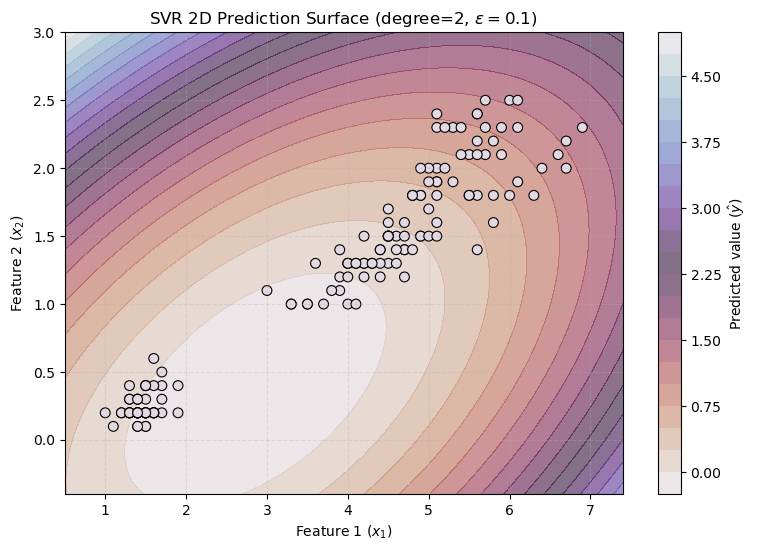

In [59]:
def plot_svm_regression_2d(svm_reg, X, y, axes):
    """Plots a 2D dataset and overlays the SVR prediction surface as a contour."""
    # 1. Create a dense 2D grid covering both features
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    
    # 2. Combine them into a 2-column input matrix to satisfy the pipeline
    X_grid = np.c_[x0.ravel(), x1.ravel()]
    
    # 3. Predict y values across the entire grid surface
    y_pred = svm_reg.predict(X_grid).reshape(x0.shape)
    
    # 4. Extract epsilon to calculate the margin boundaries
    epsilon = svm_reg.named_steps["svm_reg"].epsilon
    
    # 5. Plot the prediction surface as filled contours (the darker the color, the higher the predicted y)
    contour = plt.contourf(x0, x1, y_pred, levels=20, cmap="twilight_r", alpha=0.6)
    plt.colorbar(contour, label="Predicted value ($\hat{y}$)")
    
    # 6. Scatter your actual data points on top (colored by their true 'y' value)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=50, cmap="twilight_r", edgecolors="k", linewidth=0.8)
    
    plt.axis(axes)
    plt.xlabel("Feature 1 ($x_1$)")
    plt.ylabel("Feature 2 ($x_2$)")
    plt.grid(True, linestyle="--", alpha=0.3)

# --- Execute the Updated Plotting ---
plt.figure(figsize=(9, 6))

# Define limits for both Feature 1 and Feature 2: [x1_min, x1_max, x2_min, x2_max]
axes_limits = [X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 
               X[:, 1].min() - 0.5, X[:, 1].max() + 0.5]

plot_svm_regression_2d(poly_svm_reg, X, y, axes_limits)
plt.title(r"SVR 2D Prediction Surface (degree=2, $\epsilon=0.1$)")
plt.show()